**Explorative Datenanalyse / Dimensionsreduktion**

*Augabe DR-1*: Explorative Datenanalyse mit PCA

Generieren Sie zunächst Daten mit der Funktion createData3.py:


In [25]:
def createData3():
    # create example data
    # -------------------
    np.random.seed(42)
    numSamples = 50
    # ...cluster 1
    mu = [-4.5, 2]
    sigma = [[1, 0], [0, 4]]
    trainX = np.random.multivariate_normal(mu, sigma, numSamples)
    trainY = 1*np.ones([numSamples, 1])
    # ...cluster 2
    mu = [0, 0]
    sigma = [[1, 0], [0, 2]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, numSamples)]])
    trainY = np.block([[trainY], [2*np.ones([numSamples, 1])]])
    #...cluster 3
    mu = [5, -4]
    sigma = [[3, 0], [0, 1]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, numSamples)]])
    trainY = np.block([[trainY], [3*np.ones([numSamples, 1])]])
    return (trainX, trainY)

* Plotten Sie die Daten mit einer geeigneten Methode
* Standardisieren Sie die Daten
* Führen Sie eine PCA durch, für die Sie untenstehende Methode nutzen können und visualisieren Sie das Ergebnis
* Geben Sie die ermittelten Hauptachsen aus und visualisieren Sie sie im Plot mit den Originaldaten!

In [26]:
import numpy as np
from numpy.linalg import svd

'''
function that performs a principal component decomposition
INPUT
data Nxp matrix of N training points in p dimensions (should be
standardized)
OUTPUT
coeff pxp matrix of p Eigenvectors/principal components (columns)
in p dimensions (rows)
eigenvalues 1xp vector of Eigenvalues corresponding to the Eigenvectors
score Nxp vectors of projected data points (onto new basis)
'''
def pca_svd(data: np.array):
    # data sizes
    (N, p) = data.shape
    # Perform SVD, get Eigenvectors and -values
    # The 1D array sdiag contains the singular values
    # Each column of V=Vh.T is a principal direction (an eigenvector of
    # data^⊤*data)
    [U, sdiag, Vh] = svd(data, full_matrices=False)
    V = Vh.T.conj() # conj() only needed for non real values
    # return values
    eigenvectors = V
    eigenvalues = np.multiply(sdiag, sdiag) / (N - 1)
    # project data onto new basis
    scores = np.dot(U, np.diag(sdiag)) # same result as: np.dot(data, V)
    return (eigenvectors, eigenvalues, scores)

Eigenvalues: [1.82617598 0.18724684]
Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [-0.70710678 -0.70710678]]


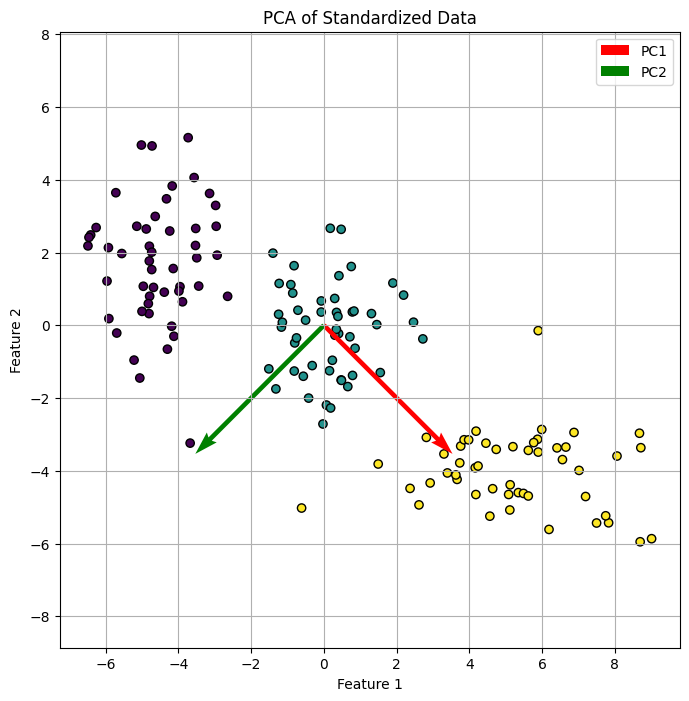

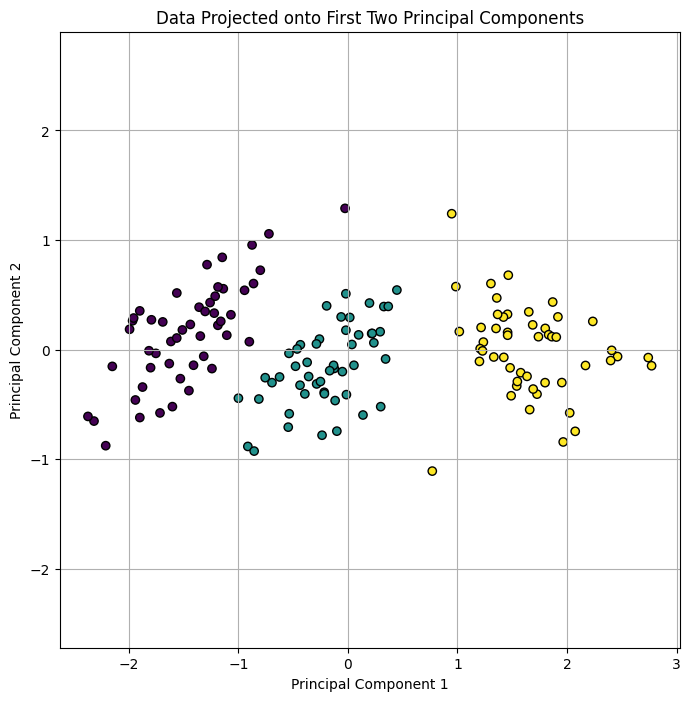

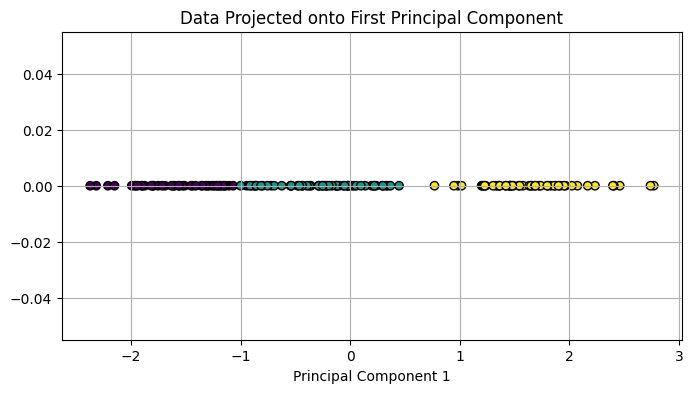

In [27]:
# TODO
(trainX, trainY) = createData3()

# standardize data from Slide page 28
meanMat = np.tile(np.mean(trainX, axis=0), (trainX.shape[0], 1))
data = trainX - meanMat
data = data / (np.tile(np.std(trainX, axis=0), (trainX.shape[0], 1)) + 1e-16)

# Perform SVD-based PCA
(eigenvectors, eigenvalues, scores) = pca_svd(data)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)
# print("Scores:\n", scores)

# Plot data and principal components
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.scatter(trainX[:, 0], trainX[:, 1], c=trainY.flatten(), cmap='viridis', edgecolor='k')
plt.quiver(0, 0, eigenvectors[0, 0] * 5, eigenvectors[1, 0] * 5, angles='xy', scale_units='xy', scale=1, color='r', label='PC1')
plt.quiver(0, 0, eigenvectors[0, 1] * 5, eigenvectors[1, 1] * 5, angles='xy', scale_units='xy', scale=1, color='g', label='PC2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('PCA of Standardized Data')
plt.legend()
plt.grid()
plt.axis('equal')
plt.show()

# Project data onto first two principal components
projectedData = scores[:, :2]
plt.figure(figsize=(8, 8))
plt.scatter(projectedData[:, 0], projectedData[:, 1], c=trainY.flatten(), cmap='viridis', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Data Projected onto First Two Principal Components')
plt.grid()
plt.axis('equal')
plt.show()

# Dimensionality reduction: keep only the first principal component
reducedData = scores[:, 0:1] # keep only the first column (PC1)
plt.figure(figsize=(8, 4))
plt.scatter(reducedData[:, 0], np.zeros_like(reducedData[:, 0]), c=trainY.flatten(), cmap='viridis', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.title('Data Projected onto First Principal Component')
plt.grid()
plt.show()

*Augabe DR-2*: Bildkompression mit PCA

Wenden Sie die PCA aus Teilaufgabe 2 auf folgendes Grauwertbild an:

    frosch_grau.jpg

Sie können das Bild mit dem Befehl

In [32]:
import matplotlib.image as mpimg

# load image
img = mpimg.imread('frosch_grau.jpg')

laden (bitte ggf. Pfad anpassen).

* Führen Sie eine PCA des Bildes durch, wobei Sie die Spalten als Features und die Zeilen als Samples interpretieren (vgl. Skript).
* Plotten Sie die (nach Varianz sortierten) Eigenwerte, um zu entscheiden, wie viele Principal Components für eine gute Rekonstruktion benötigt werden.
* Führen Sie anschließend eine Rekonstruktion des Bildes mit reduzierter Anzahl an Komponenten durch und dezentralisieren Sie das Ergebnis.
* Beschreiben Sie, wie viel Speicherplatz Sie eingespart haben!

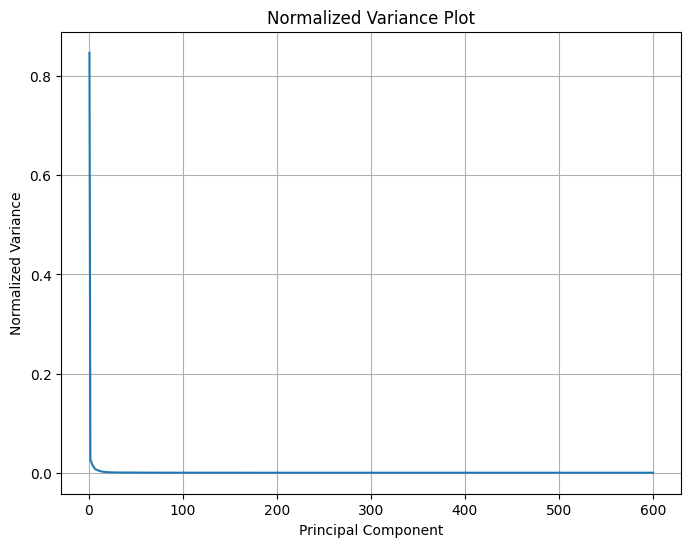

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# print(img)  # should be (height, width) for grayscale images

# standardize data from Slide page 28
(N, p) = img.shape
meanMat = np.tile(np.mean(img, axis=0), (N, 1))
data = img - meanMat
stdMat = np.tile(np.std(img, axis=0), (N, 1)) + 1e-16
data = np.divide(img, stdMat)

# Perform SVD-based PCA
(eigenvectors, eigenvalues, scores) = pca_svd(data)

# normalized variance plot
plt.figure(figsize=(8, 6))
plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues / np.sum(eigenvalues))
plt.xlabel('Principal Component')
plt.ylabel('Normalized Variance')
plt.title('Normalized Variance Plot')
plt.grid()
plt.show()



Mit einer nach Varianz ausgewählten Anzahl Principal Components erhalten wir ein gutes Rekonstruktionsergebnis:


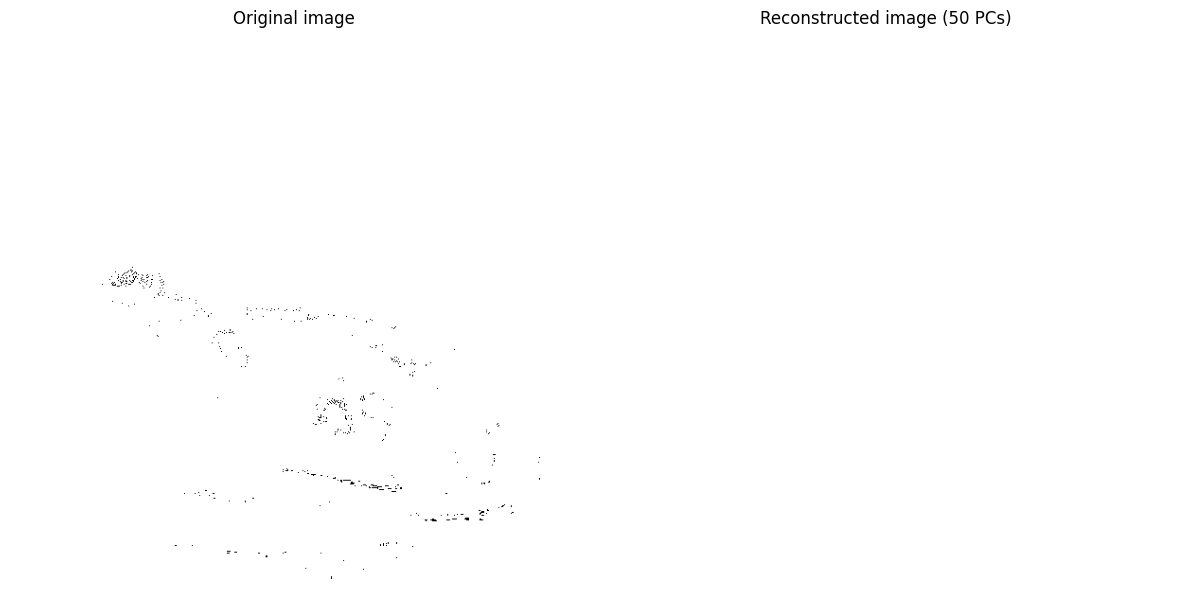

In [ ]:
k = 50

# Reconstruct the image with the retained principal components
X_recon = scores[:, :k] @ eigenvectors[:, :k].T + meanMat
X_recon = np.clip(X_recon, 0.0, 1.0)

# originalValues = X.size
# compressedValues = X.shape[0] * k + X.shape[1] * k + X.shape[1]
# savingPercent = 100.0 * (1.0 - compressedValues / originalValues)
# print(f"Compressed representation uses {compressedValues} values instead of {originalValues} original values.")
# print(f"Approximate savings: {savingPercent:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(X_recon, cmap='gray', vmin=0, vmax=1)
ax[1].set_title(f'Reconstructed image ({k} PCs)')
ax[1].axis('off')

plt.tight_layout()
plt.show()